<a href="https://colab.research.google.com/github/Aravindr017/SKINOVA/blob/model-evaluation-exporting/Model/Skinova_AI_skin_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LIBRARIES


#### 1. Environment Setup & Package Installation
Install required dependencies for data processing, image manipulation, and deep learning framework operations.

In [ ]:
%pip install -q pandas numpy opencv-python pillow matplotlib seaborn scikit-learn tqdm


Note: you may need to restart the kernel to use updated packages.


#### 2. Import Libraries & Configure Environment
Import necessary Python packages for data manipulation, computer vision, data visualization, and model development.

In [ ]:
import os

print(os.listdir("/kaggle/input"))


['datasets']


In [ ]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

In [ ]:
for dirname, dirs, files in os.walk("/kaggle/input"):
    print("\nFolder:", dirname)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:10])



Folder: /kaggle/input
Subfolders: ['datasets']
Files: []

Folder: /kaggle/input/datasets
Subfolders: ['surajghuwalewala']
Files: []

Folder: /kaggle/input/datasets/surajghuwalewala
Subfolders: ['ham1000-segmentation-and-classification']
Files: []

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification
Subfolders: ['images', 'masks']
Files: ['GroundTruth.csv']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images
Subfolders: []
Files: ['ISIC_0030912.jpg', 'ISIC_0028933.jpg', 'ISIC_0030585.jpg', 'ISIC_0028394.jpg', 'ISIC_0033697.jpg', 'ISIC_0030062.jpg', 'ISIC_0031213.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks
Subfolders: []
Files: ['ISIC_0033034_segmentation.png', 'ISIC_0026058_segmentation.png', 'ISIC_0031698_segmentation.png', 'ISIC_0032330_segmentation.png', 'ISIC_0030246_segmentation.png', 'I

In [ ]:
from pathlib import Path
import os
import pandas as pd

# ------------------------------------------------------------
# DATASET PATH
# ------------------------------------------------------------
# Find GroundTruth.csv automatically so the notebook works
# even if Kaggle changes the mounted dataset directory name.
candidates = list(Path("/kaggle/input").rglob("GroundTruth.csv"))

if not candidates:
    raise FileNotFoundError(
        "GroundTruth.csv was not found under /kaggle/input. "
        "Please attach the HAM10000 Segmentation and Classification dataset."
    )

metadata_path = candidates[0]
DATA_ROOT = metadata_path.parent

print("Dataset root:", DATA_ROOT)
print("GroundTruth.csv:", metadata_path)
print("Dataset exists:", DATA_ROOT.exists())


Dataset root: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification
GroundTruth.csv: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/GroundTruth.csv
Dataset exists: True


## Exploratory Data Analysis (EDA)
Load the ground truth labels and inspect the class distribution, missing values, and dataset size.

In [ ]:
# Load dataset metadata
df = pd.read_csv(metadata_path)

if "image" not in df.columns:
    raise ValueError(
        "GroundTruth.csv must contain an 'image' column."
    )

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (10015, 8)

Columns:
['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  object 
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), object(1)
memory usage: 626.1+ KB
None


In [ ]:
print(df.head(10))


          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
5  ISIC_0024311  0.0  1.0  0.0    0.0  0.0  0.0   0.0
6  ISIC_0024312  0.0  0.0  0.0    0.0  1.0  0.0   0.0
7  ISIC_0024313  1.0  0.0  0.0    0.0  0.0  0.0   0.0
8  ISIC_0024314  0.0  1.0  0.0    0.0  0.0  0.0   0.0
9  ISIC_0024315  1.0  0.0  0.0    0.0  0.0  0.0   0.0


In [ ]:
for root, dirs, files in os.walk(DATA_ROOT):
    print("\nFolder:", root)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:10])


Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification
Subfolders: ['images', 'masks']
Files: ['GroundTruth.csv']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images
Subfolders: []
Files: ['ISIC_0030912.jpg', 'ISIC_0028933.jpg', 'ISIC_0030585.jpg', 'ISIC_0028394.jpg', 'ISIC_0033697.jpg', 'ISIC_0030062.jpg', 'ISIC_0031213.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks
Subfolders: []
Files: ['ISIC_0033034_segmentation.png', 'ISIC_0026058_segmentation.png', 'ISIC_0031698_segmentation.png', 'ISIC_0032330_segmentation.png', 'ISIC_0030246_segmentation.png', 'ISIC_0026281_segmentation.png', 'ISIC_0024577_segmentation.png', 'ISIC_0024910_segmentation.png', 'ISIC_0031771_segmentation.png', 'ISIC_0029679_segmentation.png']


In [ ]:
# Expected HAM10000 one-hot label columns
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

missing_classes = [c for c in classes if c not in df.columns]
if missing_classes:
    raise ValueError(
        f"Missing label columns in GroundTruth.csv: {missing_classes}"
    )

label_columns = classes.copy()
print("Label columns:", label_columns)


Label columns: ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [ ]:
# Check each class
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

for col in classes:
    print(f"{col}: {df[col].sum()}")


MEL: 1113.0
NV: 6705.0
BCC: 514.0
AKIEC: 327.0
BKL: 1099.0
DF: 115.0
VASC: 142.0


In [ ]:
# ============================================================
# LABEL PREPROCESSING
# ============================================================

classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

# Convert one-hot label columns to numeric
df[classes] = df[classes].apply(pd.to_numeric, errors="coerce")
df[classes] = df[classes].fillna(0)

# A valid row must have exactly one positive class
df["label_sum"] = df[classes].sum(axis=1)

invalid_label_rows = (df["label_sum"] != 1).sum()
print("Rows with invalid label encoding:", invalid_label_rows)

df = df[df["label_sum"] == 1].copy()
df["label"] = df[classes].idxmax(axis=1)

# Fixed class order is important for reproducible model outputs.
class_to_id = {name: idx for idx, name in enumerate(classes)}
id_to_label = {idx: name for name, idx in class_to_id.items()}
df["label_id"] = df["label"].map(class_to_id).astype(int)

print("\nClass mapping:")
for class_id, class_name in id_to_label.items():
    print(f"{class_id} -> {class_name}")

print("\nClass distribution:")
print(df["label"].value_counts().reindex(classes, fill_value=0))

display(df[["image", "label", "label_id"]].head(10))


Rows with invalid label encoding: 0

Class mapping:
0 -> MEL
1 -> NV
2 -> BCC
3 -> AKIEC
4 -> BKL
5 -> DF
6 -> VASC

Class distribution:
label
MEL      1113
NV       6705
BCC       514
AKIEC     327
BKL      1099
DF        115
VASC      142
Name: count, dtype: int64


,image,label,label_id
0,ISIC_0024306,NV,1
1,ISIC_0024307,NV,1
2,ISIC_0024308,NV,1
3,ISIC_0024309,NV,1
4,ISIC_0024310,MEL,0
5,ISIC_0024311,NV,1
6,ISIC_0024312,BKL,4
7,ISIC_0024313,MEL,0
8,ISIC_0024314,NV,1
9,ISIC_0024315,MEL,0


In [ ]:
# Check image files
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

image_files = [
    path for path in DATA_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

print("Total image files found:", len(image_files))
print("\nFirst 10 images:")
for path in image_files[:10]:
    print(path)


Total image files found: 20030

First 10 images:
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030912.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028933.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030585.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030062.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0027799.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028100.jpg
/kaggle/input/d

In [ ]:
# Check for segmentation/mask files
mask_files = [
    path for path in DATA_ROOT.rglob("*")
    if path.is_file()
    and path.suffix.lower() in {".jpg", ".jpeg", ".png"}
    and any(token in path.stem.lower() for token in ["mask", "segmentation", "segment"])
]

print("Possible mask files:", len(mask_files))
for path in mask_files[:20]:
    print(path)


Possible mask files: 10015
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0033034_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0026058_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0031698_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0032330_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0030246_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0026281_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0024577_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks/ISIC_0024910_segmentation.png
/kaggle/input/datasets/surajghuwalewala/ham10

In [ ]:
#Check the image names against the CSV
print("CSV image examples:")
print(df["image"].head(10).tolist())


CSV image examples:
['ISIC_0024306', 'ISIC_0024307', 'ISIC_0024308', 'ISIC_0024309', 'ISIC_0024310', 'ISIC_0024311', 'ISIC_0024312', 'ISIC_0024313', 'ISIC_0024314', 'ISIC_0024315']


In [ ]:
print("\nActual image examples:")

for path in image_files[:10]:
    print(path.name)



Actual image examples:
ISIC_0030912.jpg
ISIC_0028933.jpg
ISIC_0030585.jpg
ISIC_0028394.jpg
ISIC_0033697.jpg
ISIC_0030062.jpg
ISIC_0031213.jpg
ISIC_0027799.jpg
ISIC_0028100.jpg
ISIC_0027960.jpg


In [ ]:
# Match CSV image IDs to actual image files.
# Use the first occurrence for duplicate stems.
image_path_dict = {}
for path in image_files:
    image_path_dict.setdefault(path.stem, str(path))

df["image_path"] = df["image"].astype(str).map(image_path_dict)

print(df[["image", "image_path"]].head(10))


          image                                         image_path
0  ISIC_0024306  /kaggle/input/datasets/surajghuwalewala/ham100...
1  ISIC_0024307  /kaggle/input/datasets/surajghuwalewala/ham100...
2  ISIC_0024308  /kaggle/input/datasets/surajghuwalewala/ham100...
3  ISIC_0024309  /kaggle/input/datasets/surajghuwalewala/ham100...
4  ISIC_0024310  /kaggle/input/datasets/surajghuwalewala/ham100...
5  ISIC_0024311  /kaggle/input/datasets/surajghuwalewala/ham100...
6  ISIC_0024312  /kaggle/input/datasets/surajghuwalewala/ham100...
7  ISIC_0024313  /kaggle/input/datasets/surajghuwalewala/ham100...
8  ISIC_0024314  /kaggle/input/datasets/surajghuwalewala/ham100...
9  ISIC_0024315  /kaggle/input/datasets/surajghuwalewala/ham100...


In [ ]:
print(
    "Images found:",
    df["image_path"].notna().sum()
)

print(
    "Images missing:",
    df["image_path"].isna().sum()
)


Images found: 10015
Images missing: 0


In [ ]:
# Remove records whose image file cannot be found
df = df.dropna(subset=["image_path"]).copy()

print("Remaining valid image records:", len(df))


Remaining valid image records: 10015


In [ ]:
# Check for corrupted images
from PIL import Image
from tqdm import tqdm

bad_images = []

for path in tqdm(df["image_path"], desc="Checking images"):
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception:
        bad_images.append(path)

print("Corrupted images:", len(bad_images))

if bad_images:
    bad_set = set(bad_images)
    df = df[~df["image_path"].isin(bad_set)].copy()
    print("Remaining records after removing corrupted images:", len(df))


Checking images: 100%|██████████| 10015/10015 [00:40<00:00, 250.16it/s]

Corrupted images: 0


In [ ]:
#Check image dimensions
from collections import Counter

sizes = []

for path in tqdm(
    df["image_path"],
    desc="Checking dimensions"
):

    with Image.open(path) as img:
        sizes.append(img.size)

print("Most common image sizes:")

for size, count in Counter(sizes).most_common(10):
    print(size, ":", count)


Checking dimensions: 100%|██████████| 10015/10015 [00:06<00:00, 1640.70it/s]

Most common image sizes:
(600, 450) : 10015


# Image Visualization
Display sample images from the dataset along with their corresponding ground truth annotations.

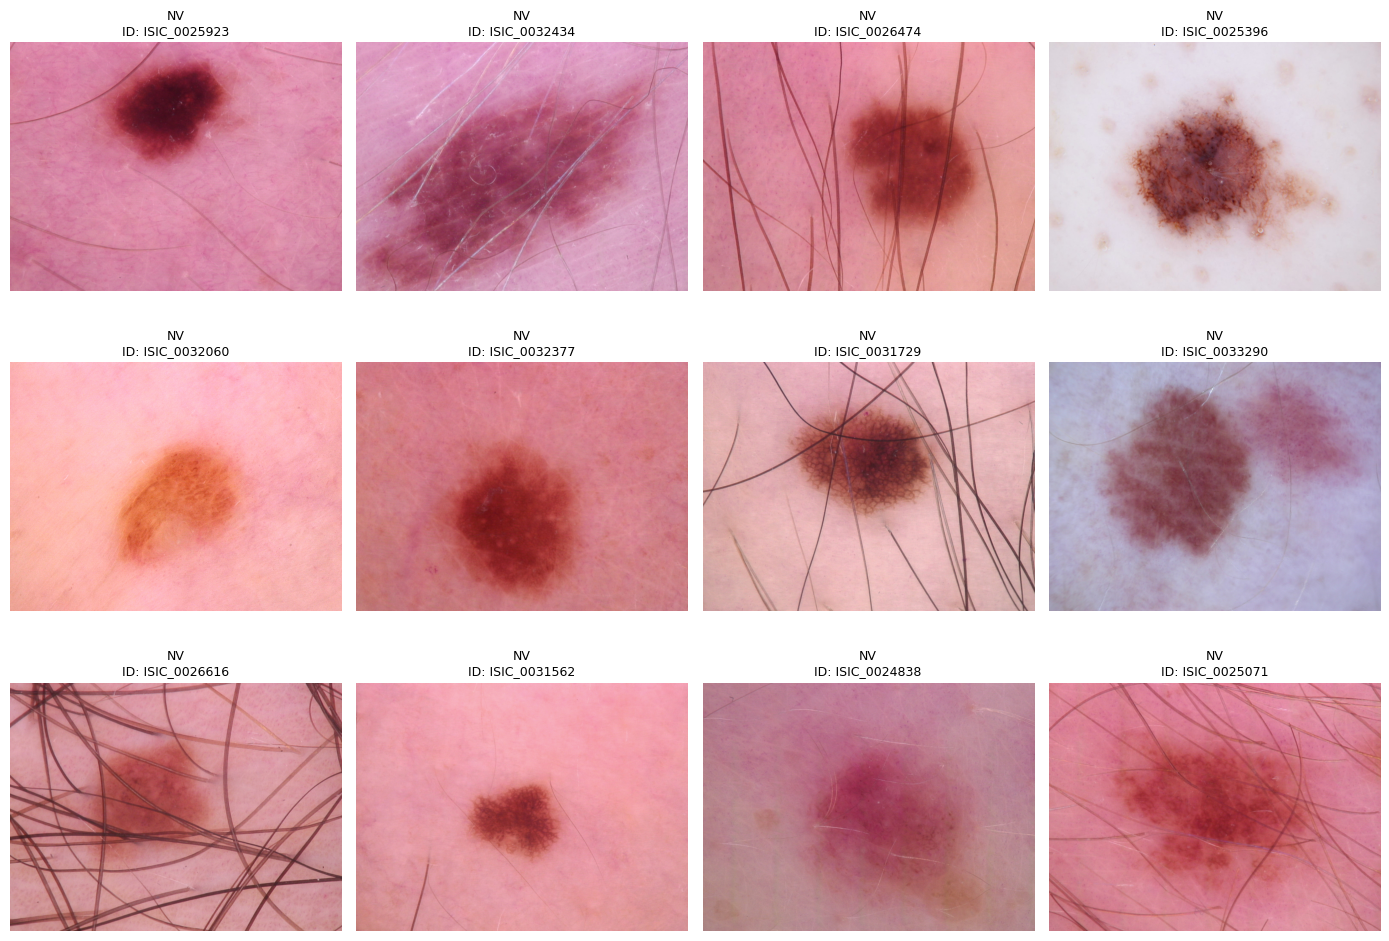

In [ ]:
# Visualize sample images
import matplotlib.pyplot as plt
from PIL import Image

sample_n = min(12, len(df))
sample_df = df.sample(sample_n, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(image)
    ax.set_title(f"{row['label']}\nID: {row['image']}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


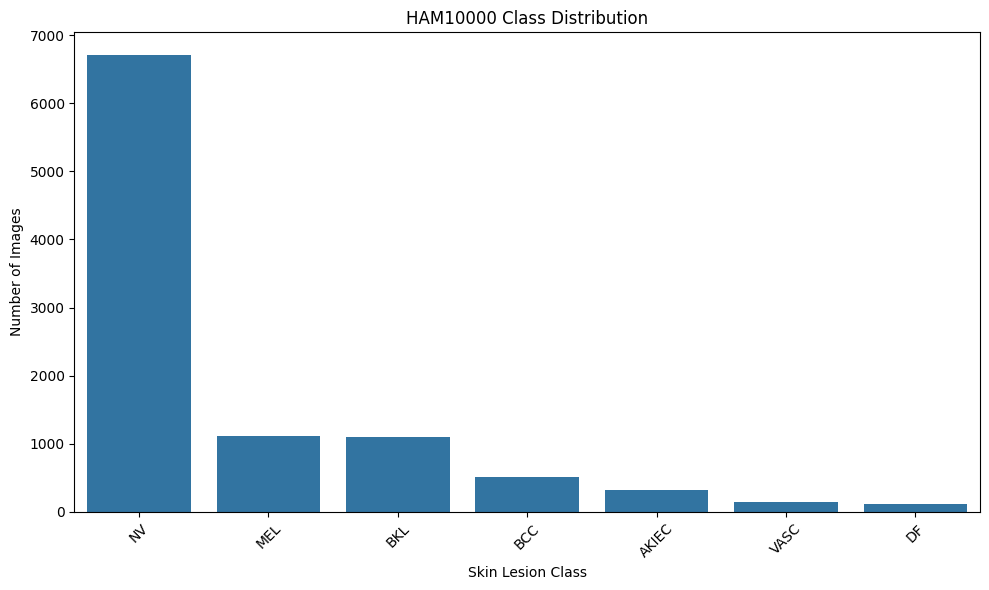

In [ ]:
#Check class distribution visually
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.title(
    "HAM10000 Class Distribution"
)

plt.xlabel("Skin Lesion Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
#display percentages
class_distribution = df["label"].value_counts()

class_percentage = (
    df["label"].value_counts(normalize=True) * 100
).round(2)

distribution_table = pd.DataFrame({
    "Count": class_distribution,
    "Percentage": class_percentage
})

display(distribution_table)

,Count,Percentage
label,,
NV,6705,66.95
MEL,1113,11.11
BKL,1099,10.97
BCC,514,5.13
AKIEC,327,3.27
VASC,142,1.42
DF,115,1.15


In [ ]:
#Save our cleaned metadata
from pathlib import Path

PROCESSED_DIR = Path("/kaggle/working/skinova_processed")

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


In [ ]:
df.to_csv(
    PROCESSED_DIR / "cleaned_metadata.csv",
    index=False
)

print(
    "Saved to:",
    PROCESSED_DIR / "cleaned_metadata.csv"
)


Saved to: /kaggle/working/skinova_processed/cleaned_metadata.csv


In [ ]:
print("Number of CSV rows:", len(df))

print("\nCSV image names:")
print(df["image"].head(10).tolist())

print("\nNumber of image files found:", len(image_files))

print("\nActual image files:")
for path in image_files[:20]:
    print(path)

print("\nNumber of mask files found:", len(mask_files))

print("\nActual mask files:")
for path in mask_files[:20]:
    print(path)


Number of CSV rows: 10015

CSV image names:
['ISIC_0024306', 'ISIC_0024307', 'ISIC_0024308', 'ISIC_0024309', 'ISIC_0024310', 'ISIC_0024311', 'ISIC_0024312', 'ISIC_0024313', 'ISIC_0024314', 'ISIC_0024315']

Number of image files found: 20030

Actual image files:
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030912.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028933.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030585.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030062.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
/kaggle/in

In [ ]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

SEED = 42

# 80% train, 10% validation, 10% test.
# Stratification preserves class proportions in all splits.
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_id"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training samples  :", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples   :", len(test_df))


Training samples  : 8012
Validation samples: 1001
Testing samples   : 1002


In [ ]:
print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())


Training distribution:
label
NV       5364
MEL       890
BKL       879
BCC       411
AKIEC     262
VASC      114
DF         92
Name: count, dtype: int64

Validation distribution:
label
NV       670
MEL      111
BKL      110
BCC       51
AKIEC     33
VASC      14
DF        12
Name: count, dtype: int64

Test distribution:
label
NV       671
MEL      112
BKL      110
BCC       52
AKIEC     32
VASC      14
DF        11
Name: count, dtype: int64


# Data Augmentation

In [ ]:
# Albumentations is used only for offline training-set balancing.
# If the package is already available, no installation is required.
try:
    import albumentations as A
except ImportError:
    %pip install -q albumentations
    import albumentations as A


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm


In [ ]:
# ============================================================
# AUGMENTATION PIPELINE
# ============================================================

augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(
        limit=15,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5
    ),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=0,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.4
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.15
    )
])

print("Augmentation pipeline created.")


Augmentation pipeline created.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
# ============================================================
# CREATE AUGMENTED DATASET DIRECTORY
# ============================================================

AUGMENTED_DIR = Path("/kaggle/working/skinova_augmented")

TRAIN_AUG_DIR = AUGMENTED_DIR / "train"

TRAIN_AUG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Augmented dataset directory:")
print(TRAIN_AUG_DIR)

Augmented dataset directory:
/kaggle/working/skinova_augmented/train


In [ ]:
# ============================================================
# TRAINING CLASS DISTRIBUTION BEFORE AUGMENTATION
# ============================================================

train_distribution = train_df["label"].value_counts().sort_index()

print("Training distribution BEFORE augmentation:")
print(train_distribution)

Training distribution BEFORE augmentation:
label
AKIEC     262
BCC       411
BKL       879
DF         92
MEL       890
NV       5364
VASC      114
Name: count, dtype: int64


In [ ]:
# ============================================================
# AUGMENTATION TARGET
# ============================================================

TARGET_IMAGES_PER_CLASS = 2000

print(
    "Target images per minority class:",
    TARGET_IMAGES_PER_CLASS
)

Target images per minority class: 2000


In [ ]:
# ============================================================
# GENERATE AUGMENTED TRAINING IMAGES
# ============================================================

augmented_records = []

# Keep all original training images
for _, row in train_df.iterrows():
    augmented_records.append({
        "image": row["image"],
        "image_path": row["image_path"],
        "label": row["label"],
        "label_id": int(row["label_id"]),
        "is_augmented": 0
    })

rng = np.random.default_rng(SEED)

# Balance each class up to the target size.
for class_name in classes:
    class_df = train_df[train_df["label"] == class_name].copy()
    current_count = len(class_df)

    images_to_generate = max(
        0,
        TARGET_IMAGES_PER_CLASS - current_count
    )

    print(
        f"{class_name}: {current_count} original -> "
        f"{current_count + images_to_generate} target"
    )

    for i in tqdm(
        range(images_to_generate),
        desc=f"Augmenting {class_name}"
    ):
        row = class_df.iloc[
            int(rng.integers(0, len(class_df)))
        ]

        image = cv2.imread(str(row["image_path"]))
        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        augmented_image = augmentation_pipeline(image=image)["image"]
        augmented_image = cv2.cvtColor(
            augmented_image,
            cv2.COLOR_RGB2BGR
        )

        original_name = Path(row["image_path"]).stem
        new_filename = f"{original_name}_aug_{i:05d}.jpg"
        output_path = TRAIN_AUG_DIR / new_filename

        ok = cv2.imwrite(
            str(output_path),
            augmented_image,
            [cv2.IMWRITE_JPEG_QUALITY, 95]
        )

        if not ok:
            continue

        augmented_records.append({
            "image": new_filename,
            "image_path": str(output_path),
            "label": row["label"],
            "label_id": int(row["label_id"]),
            "is_augmented": 1
        })

print("\nData augmentation completed.")


MEL: 890 original -> 2000 target


Augmenting MEL: 100%|██████████| 1110/1110 [00:14<00:00, 74.68it/s]


NV: 5364 original -> 5364 target


Augmenting NV: 0it [00:00, ?it/s]


BCC: 411 original -> 2000 target


...

DF: 92 original -> 2000 target


Augmenting DF: 100%|██████████| 1908/1908 [00:23<00:00, 79.77it/s]


VASC: 114 original -> 2000 target


Augmenting VASC: 100%|██████████| 1886/1886 [00:23<00:00, 79.55it/s]


Data augmentation completed.


In [ ]:
# ============================================================
# CREATE AUGMENTED TRAINING METADATA
# ============================================================

augmented_train_df = pd.DataFrame(
    augmented_records
)

print(
    "Total training images after augmentation:",
    len(augmented_train_df)
)

print("\nClass distribution AFTER augmentation:")
print(
    augmented_train_df["label"].value_counts()
)

Total training images after augmentation: 17364

Class distribution AFTER augmentation:
label
NV       5364
MEL      2000
BKL      2000
BCC      2000
DF       2000
AKIEC    2000
VASC     2000
Name: count, dtype: int64


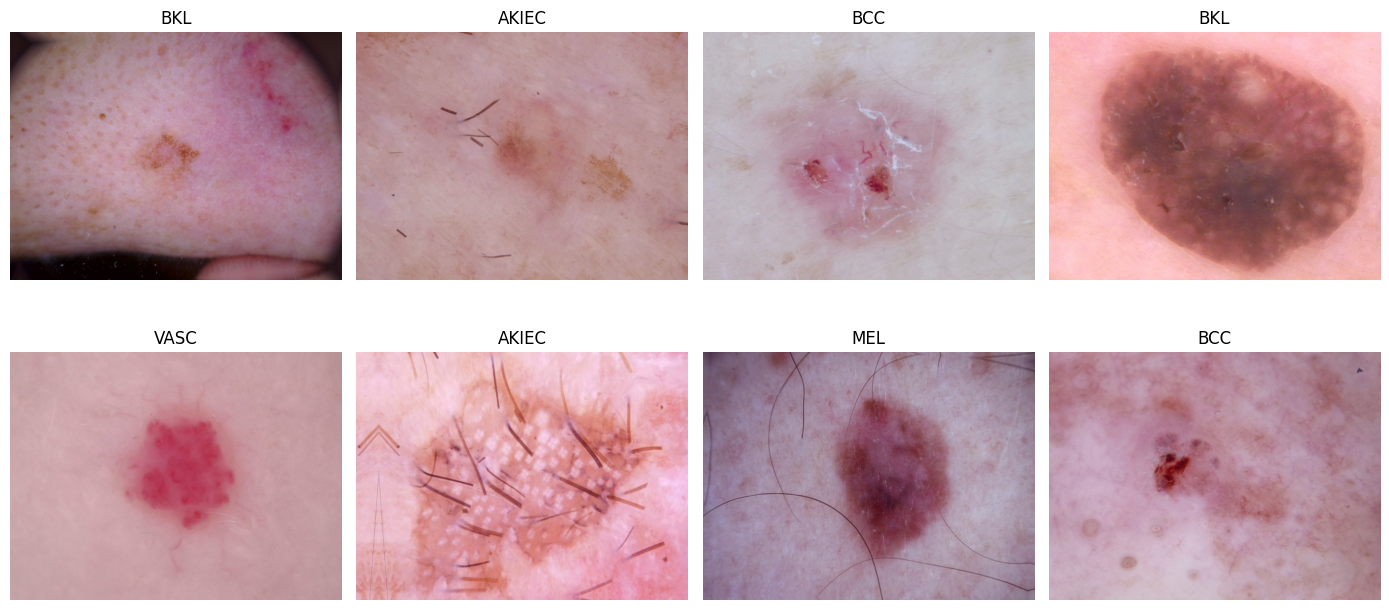

In [ ]:
# ============================================================
# VISUALIZE AUGMENTED IMAGES
# ============================================================

import matplotlib.pyplot as plt

augmented_only = augmented_train_df[
    augmented_train_df["is_augmented"] == 1
]

if len(augmented_only) == 0:
    print("No augmented images were generated.")
else:
    sample_n = min(8, len(augmented_only))
    sample_aug = augmented_only.sample(
        sample_n,
        random_state=SEED
    )

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, sample_aug.iterrows()):
        image = cv2.imread(row["image_path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        ax.imshow(image)
        ax.set_title(row["label"])
        ax.axis("off")

    plt.tight_layout()
    plt.show()


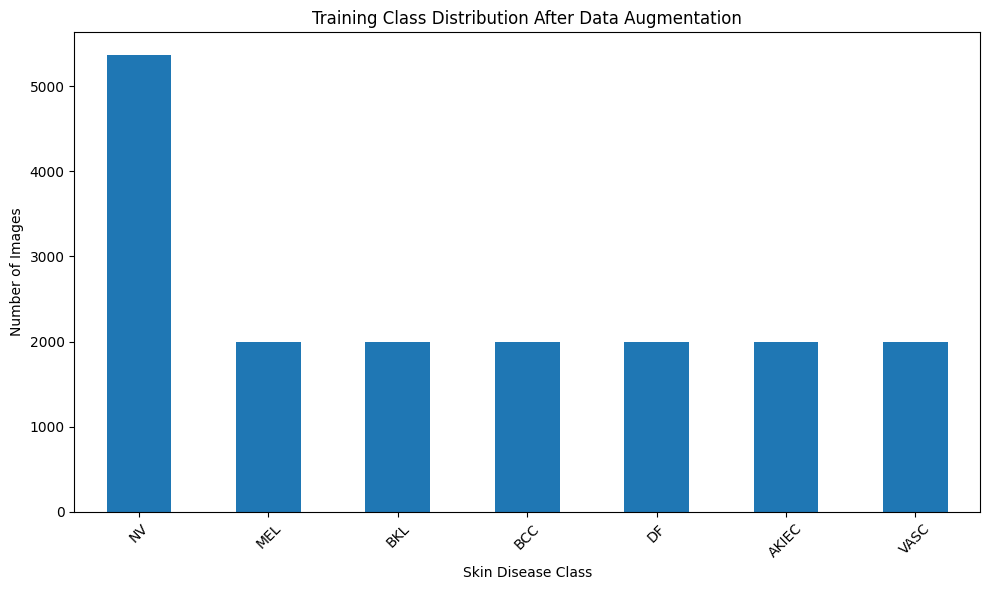

In [ ]:
# ============================================================
# CLASS DISTRIBUTION AFTER AUGMENTATION
# ============================================================

plt.figure(figsize=(10, 6))

augmented_train_df["label"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Training Class Distribution After Data Augmentation"
)

plt.xlabel("Skin Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SAVE AUGMENTED METADATA
# ============================================================

augmented_metadata_path = (
    AUGMENTED_DIR /
    "augmented_train_metadata.csv"
)

augmented_train_df.to_csv(
    augmented_metadata_path,
    index=False
)

print(
    "Augmented metadata saved to:"
)

print(
    augmented_metadata_path
)

Augmented metadata saved to:
/kaggle/working/skinova_augmented/augmented_train_metadata.csv


In [ ]:
# ============================================================
# SAVE VALIDATION AND TEST METADATA
# ============================================================

val_df.to_csv(
    AUGMENTED_DIR / "validation_metadata.csv",
    index=False
)

test_df.to_csv(
    AUGMENTED_DIR / "test_metadata.csv",
    index=False
)

print("Validation metadata saved.")
print("Test metadata saved.")

Validation metadata saved.
Test metadata saved.


# CNN Model Development

## Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Numerical and dataframe libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)


from tensorflow.keras.preprocessing.image import ImageDataGenerator


TensorFlow version: 2.20.0


## Model Configuration

In [ ]:
# Number of skin disease classes
NUM_CLASSES = 7

# Image size used for model training
IMG_SIZE = 240

# Number of images processed at one time
BATCH_SIZE = 32

# Random seed for reproducibility
SEED = 42

# Skin disease class names
CLASSES = [
    "AKIEC",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "VASC"
]

print("Number of classes:", NUM_CLASSES)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", CLASSES)

Number of classes: 7
Image size: 240
Batch size: 32
Classes: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']


## Create Training, Validation and Test Generators

In [ ]:
# No additional augmentation is applied by the generator because
# the training images were already balanced using offline augmentation.

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_dataframe(
    dataframe=augmented_train_df,
    x_col="image_path",
    y_col="label",
    classes=CLASSES,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    classes=CLASSES,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    classes=CLASSES,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nClass indices:")
print(train_generator.class_indices)


Found 17364 validated image filenames belonging to 7 classes.
Found 1001 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.

Class indices:
{'AKIEC': 0, 'BCC': 1, 'BKL': 2, 'DF': 3, 'MEL': 4, 'NV': 5, 'VASC': 6}


In [ ]:
# CHECK TRAINING DATA

train_generator.reset()
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())


Image batch shape: (32, 240, 240, 3)
Label batch shape: (32, 7)
Minimum pixel value: 0.0
Maximum pixel value: 255.0


## Visualize Training Images

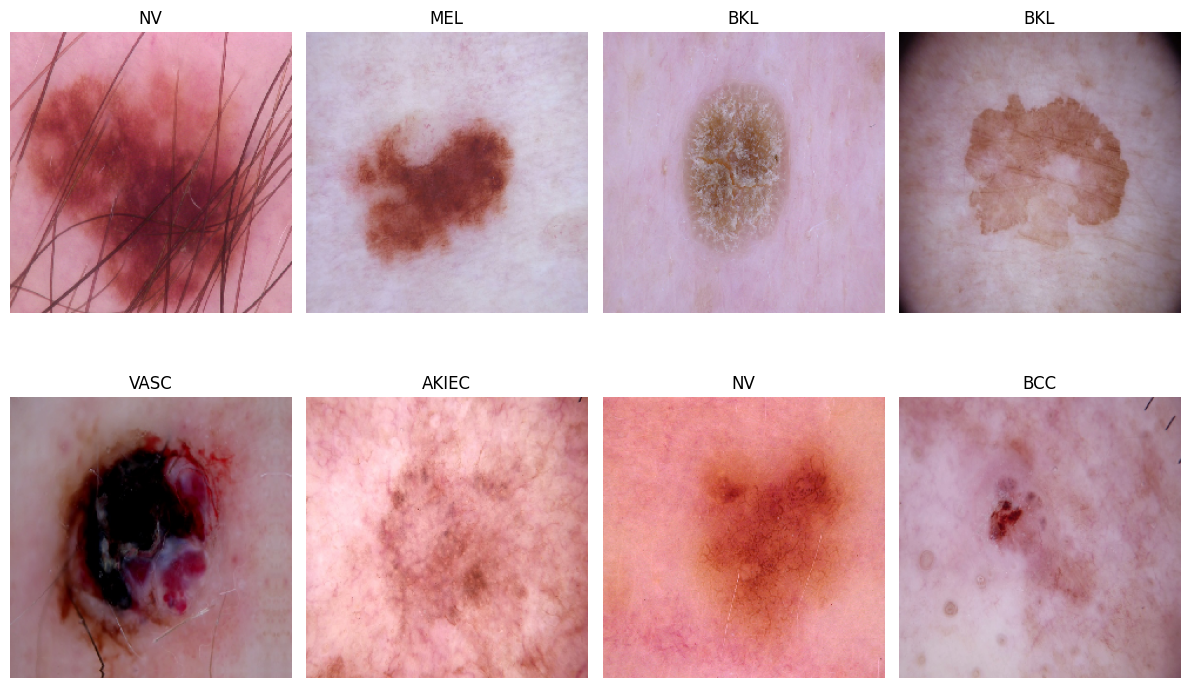

In [ ]:
# VISUALIZE TRAINING BATCH

plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i].astype("uint8"))

    # Convert one-hot encoded label into class ID
    class_id = np.argmax(labels[i])

    # Get class name
    class_name = CLASSES[class_id]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Create Training Callbacks

In [ ]:
# TRAINING CALLBACKS

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


# Stop training if validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)


# Reduce learning rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

## MODEL 1  EfficientNetB0

In [ ]:
# BUILDING EFFICIENTNETB0

from tensorflow.keras.applications import EfficientNetB0

def load_efficientnet_backbone(constructor, input_shape):
    """Load ImageNet weights when available; otherwise work offline."""
    try:
        backbone = constructor(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )
        print("ImageNet pretrained weights loaded.")
    except Exception as exc:
        print("ImageNet weights unavailable; using random initialization.")
        print("Reason:", type(exc).__name__, str(exc)[:250])
        backbone = constructor(
            include_top=False,
            weights=None,
            input_shape=input_shape
        )
    return backbone

base_b0 = load_efficientnet_backbone(
    EfficientNetB0,
    (IMG_SIZE, IMG_SIZE, 3)
)
base_b0.trainable = False

efficientnet_b0 = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_b0,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

efficientnet_b0.summary()


I0000 00:00:1789445665.145129      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789445665.148250      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ImageNet pretrained weights loaded.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,426 (16.73 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Compile EfficientNetB0

In [ ]:
efficientnet_b0.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

print("EfficientNetB0 compiled successfully.")

EfficientNetB0 compiled successfully.


## Train EfficientNetB0

In [ ]:
checkpoint_b0 = ModelCheckpoint(
    "/kaggle/working/skinova_efficientnetb0_best.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1
)


history_b0 = efficientnet_b0.fit(

    train_generator,

    validation_data=val_generator,

    epochs=15,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_b0
    ]
)

Epoch 1/15


2026-09-15 04:14:48.589454: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:14:48.735186: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:14:49.096561: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:14:49.240399: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:14:50.102331: E external/local_xla/xla/stream_

380/543 ━━━━━━━━━━━━━━━━━━━━ 26s 162ms/step - accuracy: 0.3652 - loss: 1.8669

2026-09-15 04:16:07.556414: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:16:07.698867: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:16:08.055008: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:16:08.199524: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:16:08.343064: E external/local_xla/xla/stream_

543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.4026 - loss: 1.7422

2026-09-15 04:17:07.672510: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:17:07.809511: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:17:08.142031: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:17:08.291557: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:17:08.434739: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.73327, saving model to /kaggle/working/skinova_efficientnetb0_best.keras

Epoch 1: finished saving model to /kaggle/working/skinova_efficientnetb0_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 166s 252ms/step - accuracy: 0.5073 - loss: 1.3938 - val_accuracy: 0.7333 - val_loss: 0.7899 - learning_rate: 1.0000e-04
Epoch 2/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.6479 - loss: 0.9657
Epoch 2: val_accuracy improved from 0.73327 to 0.77522, saving model to /kaggle/working/skinova_efficientnetb0_best.keras

Epoch 2: finished saving model to /kaggle/working/skinova_efficientnetb0_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 101s 186ms/step - accuracy: 0.6613 - loss: 0.9323 - val_accuracy: 0.7752 - val_loss: 0.6833 - learning_rate: 1.0000e-04
Epoch 3/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7105 - loss: 0.8070
Epoch 3: val_accuracy did not improve from 0.77522
543/543 ━━━━━━━━━━━━━━━━━━━━ 95s 175ms/step - accuracy: 0.7173 

## Plot EfficientNetB0 Training Results

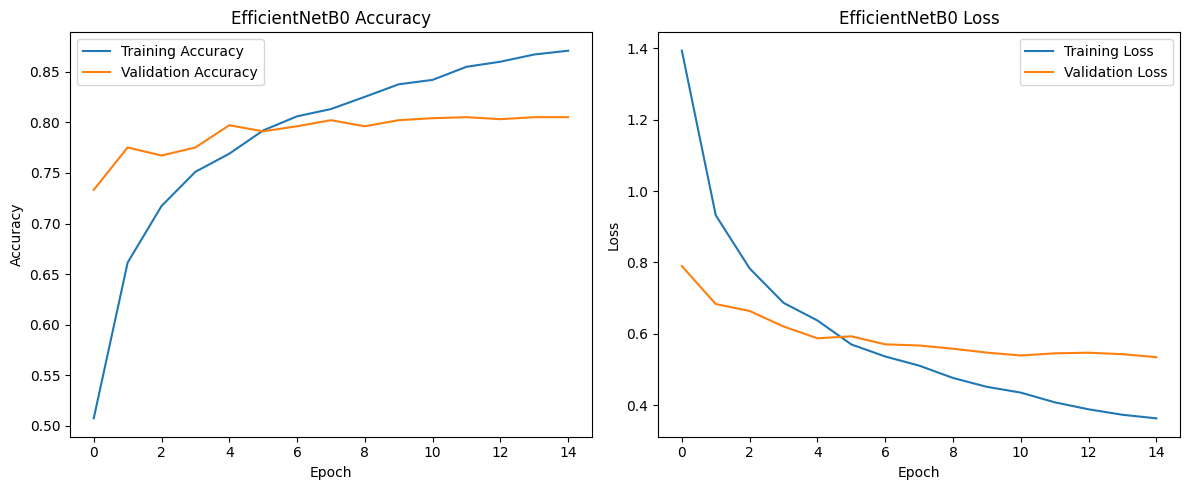

In [ ]:
plt.figure(figsize=(12, 5))

# Training and validation accuracy
plt.subplot(1, 2, 1)

plt.plot(
    history_b0.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_b0.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNetB0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Training and validation loss
plt.subplot(1, 2, 2)

plt.plot(
    history_b0.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_b0.history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNetB0 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Fine-Tune EfficientNetB0

In [ ]:
# Unfreeze the EfficientNetB0 base model
base_b0.trainable = True


# Freeze earlier layers
# Only the last 30 layers will be trainable
for layer in base_b0.layers[:-30]:

    layer.trainable = False


# Keep BatchNormalization layers frozen
# This helps maintain stable pretrained statistics
for layer in base_b0.layers:

    if isinstance(layer, layers.BatchNormalization):

        layer.trainable = False


# Recompile with a smaller learning rate
efficientnet_b0.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)


print("EfficientNetB0 ready for fine-tuning.")

EfficientNetB0 ready for fine-tuning.


In [ ]:
history_b0_finetune = efficientnet_b0.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_b0
    ]
)

# Reload the best checkpoint after fine-tuning.
efficientnet_b0_best = keras.models.load_model(
    "/kaggle/working/skinova_efficientnetb0_best.keras"
)

print("Best EfficientNetB0 checkpoint reloaded.")


Epoch 1/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.8791 - loss: 0.3437
Epoch 1: val_accuracy improved from 0.80519 to 0.81818, saving model to /kaggle/working/skinova_efficientnetb0_best.keras

Epoch 1: finished saving model to /kaggle/working/skinova_efficientnetb0_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 155s 234ms/step - accuracy: 0.8770 - loss: 0.3433 - val_accuracy: 0.8182 - val_loss: 0.5239 - learning_rate: 1.0000e-05
Epoch 2/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8832 - loss: 0.3312
Epoch 2: val_accuracy improved from 0.81818 to 0.82218, saving model to /kaggle/working/skinova_efficientnetb0_best.keras

Epoch 2: finished saving model to /kaggle/working/skinova_efficientnetb0_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 97s 179ms/step - accuracy: 0.8848 - loss: 0.3233 - val_accuracy: 0.8222 - val_loss: 0.5050 - learning_rate: 1.0000e-05
Epoch 3/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8943 - loss: 0.3097
Epoch 3: val_accuracy did

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt

test_generator.reset()
predictions = efficientnet_b0_best.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = CLASSES

print("EfficientNetB0 Classification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=class_names,
        digits=4,
        zero_division=0
)
)


31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step

2026-09-15 04:56:52.031842: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:56:52.171098: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:56:52.501577: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:56:52.645844: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:56:53.469280: E external/local_xla/xla/stream_

32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 650ms/step
EfficientNetB0 Classification Report:

              precision    recall  f1-score   support

       AKIEC     0.5366    0.6875    0.6027        32
         BCC     0.7037    0.7308    0.7170        52
         BKL     0.6404    0.5182    0.5729       110
          DF     1.0000    0.8182    0.9000        11
         MEL     0.5596    0.5446    0.5520       112
          NV     0.8952    0.9165    0.9057       671
        VASC     0.7692    0.7143    0.7407        14

    accuracy                         0.8104      1002
   macro avg     0.7293    0.7043    0.7130      1002
weighted avg     0.8077    0.8104    0.8078      1002



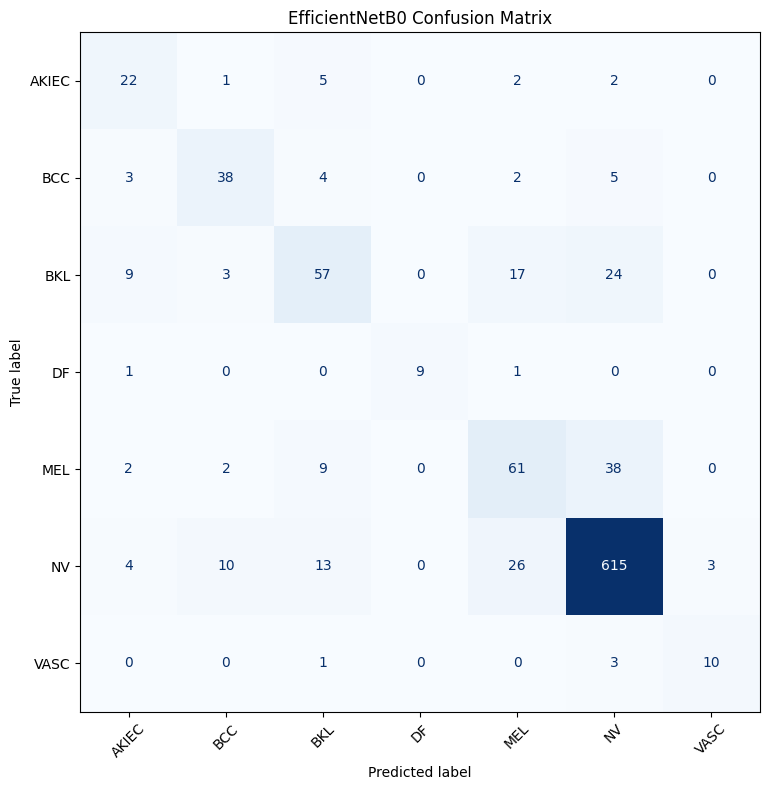

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False
)
ax.set_title("EfficientNetB0 Confusion Matrix")
plt.tight_layout()
plt.show()


## Save EfficientNetB0

In [ ]:
efficientnet_b0_best.save(
    "/kaggle/working/skinova_efficientnetb0_final.keras"
)
print("EfficientNetB0 best model saved successfully.")


EfficientNetB0 best model saved successfully.


## MODEL 2  EfficientNetB1

## Build EfficientNetB1

In [ ]:
from tensorflow.keras.applications import EfficientNetB1

base_b1 = load_efficientnet_backbone(
    EfficientNetB1,
    (IMG_SIZE, IMG_SIZE, 3)
)
base_b1.trainable = False

efficientnet_b1 = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_b1,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

efficientnet_b1.summary()


27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ImageNet pretrained weights loaded.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb1 (Functional)     │ (None, 8, 8, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,910,094 (26.36 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 6,577,799 (25.09 MB)

## Compile EfficentNetB1

In [ ]:
efficientnet_b1.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

print("EfficientNetB1 compiled successfully.")

EfficientNetB1 compiled successfully.


## Train EfficientNetB1

In [ ]:
checkpoint_b1 = ModelCheckpoint(

    "/kaggle/working/skinova_efficientnetb1_best.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1
)


history_b1 = efficientnet_b1.fit(

    train_generator,

    validation_data=val_generator,

    epochs=15,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_b1
    ]
)

Epoch 1/15


2026-09-15 04:57:23.688504: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:57:23.852275: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:57:24.016966: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


197/543 ━━━━━━━━━━━━━━━━━━━━ 51s 150ms/step - accuracy: 0.2878 - loss: 2.2765

2026-09-15 04:58:11.539098: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:58:11.703542: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.3856 - loss: 1.8689

2026-09-15 04:59:36.366668: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 04:59:36.530497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.72428, saving model to /kaggle/working/skinova_efficientnetb1_best.keras

Epoch 1: finished saving model to /kaggle/working/skinova_efficientnetb1_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 161s 234ms/step - accuracy: 0.4887 - loss: 1.4770 - val_accuracy: 0.7243 - val_loss: 0.7707 - learning_rate: 1.0000e-04
Epoch 2/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6208 - loss: 1.0395
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 2: val_accuracy improved from 0.72428 to 0.74026, saving model to /kaggle/working/skinova_efficientnetb1_best.keras

Epoch 2: finished saving model to /kaggle/working/skinova_efficientnetb1_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 91s 167ms/step - accuracy: 0.6349 - loss: 0.9921 - val_accuracy: 0.7403 - val_loss: 0.7038 - learning_rate: 1.0000e-04
Epoch 3/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.6862 - loss: 0.8541
Epoch 3: val_accuracy improved from 0.

## Plot EfficientNetB1 Training Results

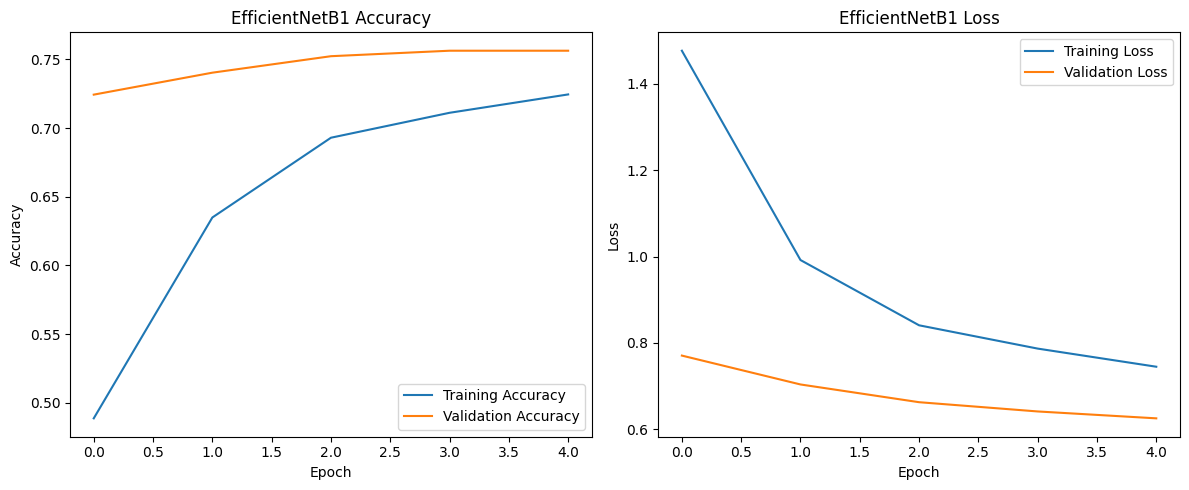

In [ ]:
plt.figure(figsize=(12, 5))


# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    history_b1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_b1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNetB1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Loss
plt.subplot(1, 2, 2)

plt.plot(
    history_b1.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_b1.history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNetB1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.tight_layout()
plt.show()

## Fine-Tune EfficientNetB1

In [ ]:
# Unfreeze the base model
base_b1.trainable = True


# Freeze earlier layers
for layer in base_b1.layers[:-30]:

    layer.trainable = False


# Keep BatchNormalization layers frozen
for layer in base_b1.layers:

    if isinstance(layer, layers.BatchNormalization):

        layer.trainable = False


# Recompile using a smaller learning rate
efficientnet_b1.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)


print("EfficientNetB1 ready for fine-tuning.")

EfficientNetB1 ready for fine-tuning.


In [ ]:
history_b1_finetune = efficientnet_b1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_b1
    ]
)

efficientnet_b1_best = keras.models.load_model(
    "/kaggle/working/skinova_efficientnetb1_best.keras"
)

print("Best EfficientNetB1 checkpoint reloaded.")


Epoch 1/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.6111 - loss: 1.0470
Epoch 1: val_accuracy did not improve from 0.75624
543/543 ━━━━━━━━━━━━━━━━━━━━ 165s 236ms/step - accuracy: 0.6275 - loss: 1.0161 - val_accuracy: 0.7383 - val_loss: 0.7230 - learning_rate: 1.0000e-05
Epoch 2/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.6597 - loss: 0.9250
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_accuracy did not improve from 0.75624
543/543 ━━━━━━━━━━━━━━━━━━━━ 92s 170ms/step - accuracy: 0.6619 - loss: 0.9147 - val_accuracy: 0.7423 - val_loss: 0.6850 - learning_rate: 1.0000e-05
Epoch 3/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.6876 - loss: 0.8605
Epoch 3: val_accuracy did not improve from 0.75624
543/543 ━━━━━━━━━━━━━━━━━━━━ 94s 173ms/step - accuracy: 0.6906 - loss: 0.8532 - val_accuracy: 0.7522 - val_loss: 0.6633 - learning_rate: 5.0000e-06
Epoch 4/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accur

## Compare B0 and B1

In [ ]:
# Compare the best checkpoints, not merely the last in-memory epoch.

b0_loss, b0_accuracy = efficientnet_b0_best.evaluate(
    test_generator,
    verbose=0
)

b1_loss, b1_accuracy = efficientnet_b1_best.evaluate(
    test_generator,
    verbose=0
)

comparison = pd.DataFrame({
    "Model": ["EfficientNetB0", "EfficientNetB1"],
    "Test Loss": [b0_loss, b1_loss],
    "Test Accuracy": [b0_accuracy, b1_accuracy]
})

display(comparison)


2026-09-15 05:15:36.403779: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:15:36.568304: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


,Model,Test Loss,Test Accuracy
0,EfficientNetB0,0.513403,0.810379
1,EfficientNetB1,0.664841,0.753493


## Save EfficientNetB1

In [ ]:
efficientnet_b1_best.save(
    "/kaggle/working/skinova_efficientnetb1_final.keras"
)
print("EfficientNetB1 best model saved successfully.")


EfficientNetB1 best model saved successfully.


## Create the final prediction function

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import os

# Use the best EfficientNetB1 checkpoint as the final model.
model = efficientnet_b1_best
CLASS_NAMES = CLASSES.copy()

def predict_skin_disease(
    image_path,
    model=model,
    class_names=CLASS_NAMES,
    top_k=3
):
    """Return top-k predictions for one skin-lesion image."""

    if not isinstance(image_path, (str, os.PathLike)):
        raise TypeError("image_path must be a file path string.")

    image_path = str(image_path)

    if not os.path.isfile(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    top_k = min(int(top_k), len(class_names))
    if top_k < 1:
        raise ValueError("top_k must be at least 1.")

    image = load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )
    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]

    top_indices = np.argsort(probabilities)[::-1][:top_k]

    predictions = [
        {
            "class": class_names[int(idx)],
            "confidence": float(probabilities[int(idx)])
        }
        for idx in top_indices
    ]

    return {
        "predicted_class": predictions[0]["class"],
        "confidence": predictions[0]["confidence"],
        "top_predictions": predictions
    }


def predict_multiple_images(
    image_paths,
    model=model,
    class_names=CLASS_NAMES,
    top_k=3
):
    """Predict skin disease classes for multiple image paths."""

    results = []

    for image_path in image_paths:
        result = predict_skin_disease(
            image_path,
            model=model,
            class_names=class_names,
            top_k=top_k
        )

        results.append({
            "image": image_path,
            "predicted_class": result["predicted_class"],
            "confidence": result["confidence"],
            "top_predictions": result["top_predictions"]
        })

    return results

print("Prediction functions created successfully.")
print("Final model:", model.name)
print("Classes:", CLASS_NAMES)


Prediction functions created successfully.
Final model: sequential_1
Classes: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']


In [ ]:
# TEST PREDICTION ON SAMPLE IMAGES

sample_image_paths = [
    str(DATA_ROOT / "images" / "ISIC_0028394.jpg"),
    str(DATA_ROOT / "images" / "ISIC_0033697.jpg"),
    str(DATA_ROOT / "images" / "ISIC_0031213.jpg")
]

results = predict_multiple_images(
    sample_image_paths,
    model=model,
    class_names=CLASS_NAMES,
    top_k=3
)

for result in results:
    print("\\nImage:", result["image"])
    print("Predicted class:", result["predicted_class"])
    print("Confidence:", f'{result["confidence"]:.2%}')
    print("Top-3 predictions:")
    for pred in result["top_predictions"]:
        print(f'  {pred["class"]}: {pred["confidence"]:.2%}')


2026-09-15 05:15:52.467325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:15:52.603404: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:15:53.411133: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:15:53.547526: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-15 05:15:54.365531: E external/local_xla/xla/stream_

\nImage: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
Predicted class: NV
Confidence: 99.50%
Top-3 predictions:
  NV: 99.50%
  DF: 0.31%
  BKL: 0.09%
\nImage: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
Predicted class: NV
Confidence: 74.65%
Top-3 predictions:
  NV: 74.65%
  DF: 13.44%
  MEL: 8.52%
\nImage: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
Predicted class: NV
Confidence: 99.94%
Top-3 predictions:
  NV: 99.94%
  VASC: 0.03%
  MEL: 0.02%


## Return Top-3 predictions

In [ ]:
# ============================================================
# SIMPLE TOP-3 PREDICTION HELPER
# ============================================================

def predict_top3(image_path, model=model, class_names=CLASS_NAMES):
    """Return top-3 predictions as a list of dictionaries."""
    result = predict_skin_disease(
        image_path=image_path,
        model=model,
        class_names=class_names,
        top_k=3
    )
    return result["top_predictions"]


top3 = predict_top3(sample_image_paths[0])
print(top3)




[{'class': 'NV', 'confidence': 0.9950389266014099}, {'class': 'DF', 'confidence': 0.003114947583526373}, {'class': 'BKL', 'confidence': 0.0008733836584724486}]


# Model Evaluation

## Evaluate EfficientNetB0

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the best EfficientNetB0 checkpoint
efficientnet_b0_best = load_model(
    "/kaggle/working/skinova_efficientnetb0_best.keras"
)

test_generator.reset()
loss_b0, accuracy_b0 = efficientnet_b0_best.evaluate(
    test_generator,
    verbose=1
)

print(f"EfficientNetB0 Test Loss: {loss_b0:.4f}")
print(f"EfficientNetB0 Test Accuracy: {accuracy_b0:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 362ms/step - accuracy: 0.8104 - loss: 0.5134
EfficientNetB0 Test Loss: 0.5134
EfficientNetB0 Test Accuracy: 0.8104


32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 449ms/step

EfficientNetB0 Classification Report:
              precision    recall  f1-score   support

       AKIEC     0.5366    0.6875    0.6027        32
         BCC     0.7037    0.7308    0.7170        52
         BKL     0.6404    0.5182    0.5729       110
          DF     1.0000    0.8182    0.9000        11
         MEL     0.5596    0.5446    0.5520       112
          NV     0.8952    0.9165    0.9057       671
        VASC     0.7692    0.7143    0.7407        14

    accuracy                         0.8104      1002
   macro avg     0.7293    0.7043    0.7130      1002
weighted avg     0.8077    0.8104    0.8078      1002



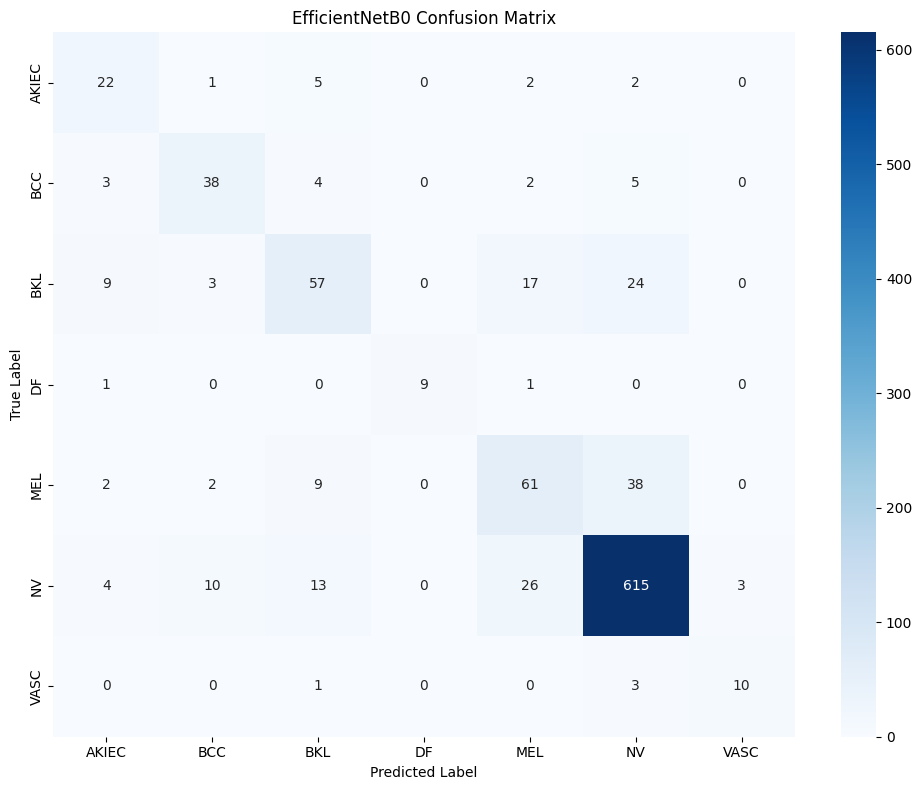

In [ ]:
test_generator.reset()

y_pred_b0 = efficientnet_b0_best.predict(
    test_generator,
    verbose=1
)
y_pred_classes_b0 = np.argmax(y_pred_b0, axis=1)
y_true_classes = test_generator.classes

class_labels = CLASSES.copy()

print("\nEfficientNetB0 Classification Report:")
print(
    classification_report(
        y_true_classes,
        y_pred_classes_b0,
        labels=list(range(NUM_CLASSES)),
        target_names=class_labels,
        digits=4,
        zero_division=0
    )
)

cm_b0 = confusion_matrix(
    y_true_classes,
    y_pred_classes_b0,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_b0,
    annot=True,
    fmt="g",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 Confusion Matrix")
plt.tight_layout()
plt.show()


## Evaluate EfficientNetB1

In [ ]:
# Load the best EfficientNetB1 checkpoint
efficientnet_b1_best = load_model(
    "/kaggle/working/skinova_efficientnetb1_best.keras"
)

test_generator.reset()
loss_b1, accuracy_b1 = efficientnet_b1_best.evaluate(
    test_generator,
    verbose=1
)

print(f"EfficientNetB1 Test Loss: {loss_b1:.4f}")
print(f"EfficientNetB1 Test Accuracy: {accuracy_b1:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 418ms/step - accuracy: 0.7535 - loss: 0.6648
EfficientNetB1 Test Loss: 0.6648
EfficientNetB1 Test Accuracy: 0.7535


32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 512ms/step

EfficientNetB1 Classification Report:
              precision    recall  f1-score   support

       AKIEC     0.4082    0.6250    0.4938        32
         BCC     0.5385    0.6731    0.5983        52
         BKL     0.5234    0.5091    0.5161       110
          DF     0.3333    0.8182    0.4737        11
         MEL     0.4909    0.4821    0.4865       112
          NV     0.9091    0.8495    0.8783       671
        VASC     0.6471    0.7857    0.7097        14

    accuracy                         0.7535      1002
   macro avg     0.5501    0.6775    0.5938      1002
weighted avg     0.7748    0.7535    0.7611      1002



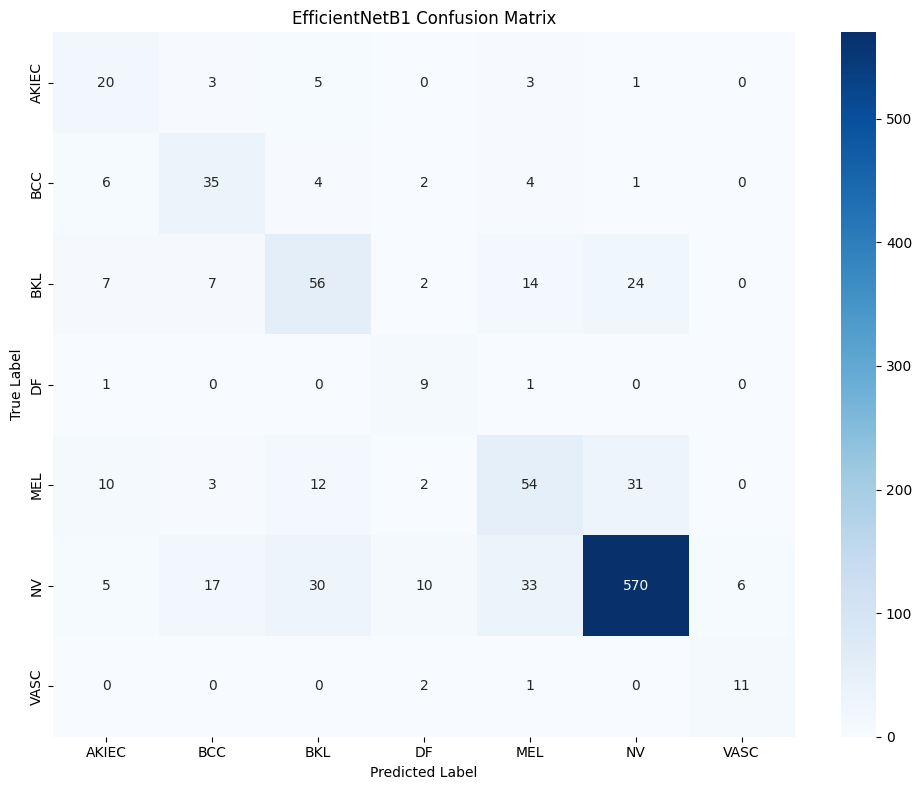

In [ ]:
test_generator.reset()

y_pred_b1 = efficientnet_b1_best.predict(
    test_generator,
    verbose=1
)
y_pred_classes_b1 = np.argmax(y_pred_b1, axis=1)

print("\nEfficientNetB1 Classification Report:")
print(
    classification_report(
        y_true_classes,
        y_pred_classes_b1,
        labels=list(range(NUM_CLASSES)),
        target_names=class_labels,
        digits=4,
        zero_division=0
    )
)

cm_b1 = confusion_matrix(
    y_true_classes,
    y_pred_classes_b1,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_b1,
    annot=True,
    fmt="g",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB1 Confusion Matrix")
plt.tight_layout()
plt.show()


# Model Exporting

## Exporting Models for Web Applications

In [ ]:
import tensorflow as tf
from pathlib import Path

export_path_b0 = Path("/kaggle/working/efficientnet_b0_savedmodel")
export_path_b1 = Path("/kaggle/working/efficientnet_b1_savedmodel")

def export_saved_model(model, export_path):
    export_path = str(export_path)

    if hasattr(model, "export"):
        model.export(export_path, verbose=0)
    else:
        tf.saved_model.save(model, export_path)

    print(f"Exported: {export_path}")

export_saved_model(efficientnet_b0_best, export_path_b0)
export_saved_model(efficientnet_b1_best, export_path_b1)

print("Model export completed successfully.")

INFO:tensorflow:Assets written to: /kaggle/working/efficientnet_b0_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/efficientnet_b0_savedmodel/assets


Exported: /kaggle/working/efficientnet_b0_savedmodel
INFO:tensorflow:Assets written to: /kaggle/working/efficientnet_b1_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/efficientnet_b1_savedmodel/assets


Exported: /kaggle/working/efficientnet_b1_savedmodel
Model export completed successfully.
